# 🩺 Exploratory Data Analysis: Hospital Readmissions

In this notebook, we explore the UCI Diabetes 130-US hospital dataset to understand data distribution, class imbalance, outliers, and missing values before modeling.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("../data/diabetic_data.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 🔍 Missing Values & Duplicates

Missing values:
max_glu_serum    96420
A1Cresult        84748
dtype: int64


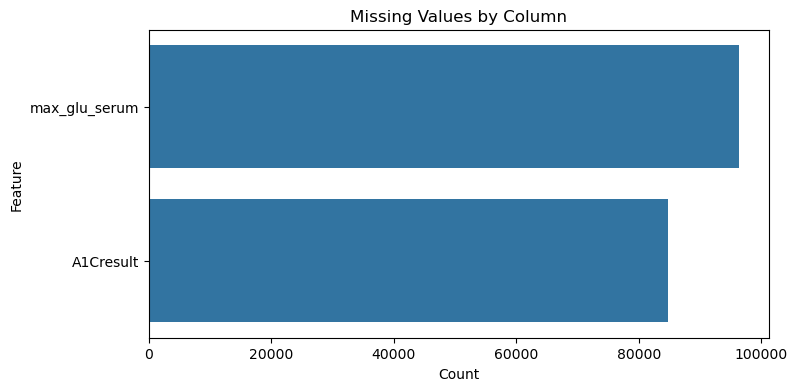


Duplicate rows:
0


In [2]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Missing values:")
print(missing)

# Plot
plt.figure(figsize=(8, 4))
sns.barplot(x=missing.values, y=missing.index)
plt.title("Missing Values by Column")
plt.xlabel("Count")
plt.ylabel("Feature")
plt.show()

# Duplicate rows
print("\nDuplicate rows:")
print(df.duplicated().sum())

## 🎯 Readmission Label Distribution

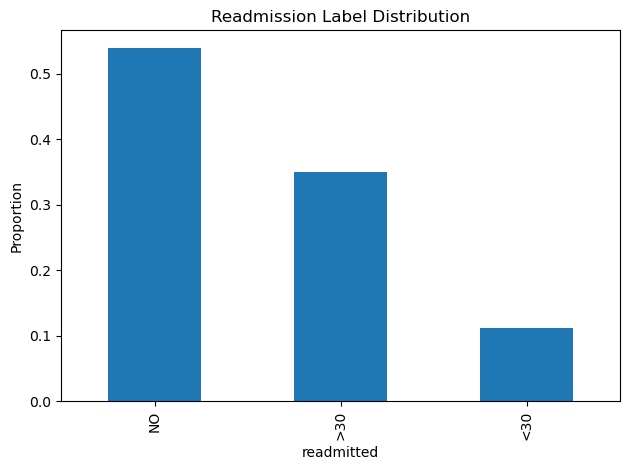

In [3]:
df['readmitted'].value_counts(normalize=True).plot(
    kind='bar', title='Readmission Label Distribution'
)
plt.ylabel("Proportion")
plt.xlabel("readmitted")
plt.tight_layout()
plt.show()

## 📊 Categorical Feature Distributions

In [4]:
# Gender
print("Gender value counts:")
print(df['gender'].value_counts())

# Race
print("\nRace value counts:")
print(df['race'].value_counts())

# Age
print("\nAge value counts:")
print(df['age'].value_counts())

Gender value counts:
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

Race value counts:
race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

Age value counts:
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64


## 📉 Outlier Detection: `num_lab_procedures`

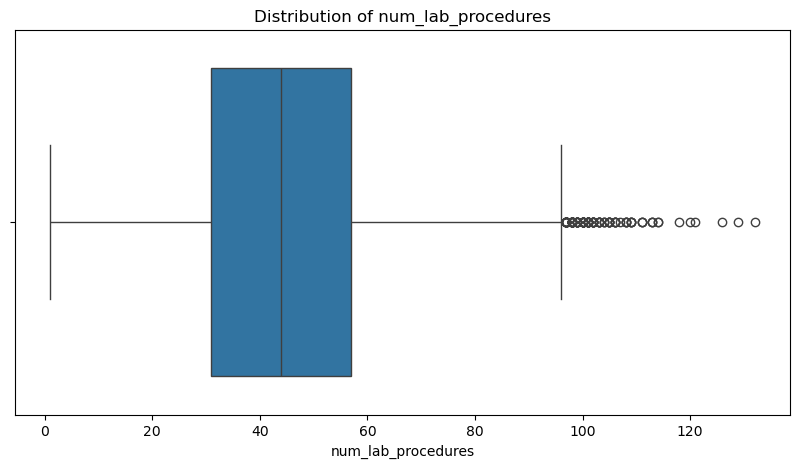

In [5]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['num_lab_procedures'])
plt.title("Distribution of num_lab_procedures")
plt.xlabel("num_lab_procedures")
plt.show()